# 📊 EduPulse

## AI-Powered Instructor Effectiveness Analytics

### Problem Statement

Educational institutions generate large volumes of engagement and performance data that can be leveraged to evaluate instructor effectiveness. This project applies machine learning techniques to analyze instructor-related metrics and predict instructional performance based on learner engagement, assessment outcomes, and course interaction patterns.

The objective is to identify the factors that contribute most to instructor effectiveness and compare multiple machine learning models to determine the best predictive approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/raw/instructor_effectiveness.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_quiz_score,dropout_rate,avg_watch_time,feedback_response_rate,avg_score_improvement,assignment_submission_rate,avg_feedback_score,forum_activity_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.5331930414
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.7340874215
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.6814332201
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.6967098405


In [4]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (1995, 12)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    1995 non-null   str    
 1   instructor_id               1995 non-null   str    
 2   course_id                   1995 non-null   str    
 3   completion_rate             1995 non-null   float64
 4   avg_quiz_score              1995 non-null   float64
 5   dropout_rate                1995 non-null   float64
 6   avg_watch_time              1995 non-null   float64
 7   feedback_response_rate      1995 non-null   float64
 8   avg_score_improvement       1995 non-null   float64
 9   assignment_submission_rate  1995 non-null   float64
 10  avg_feedback_score          1995 non-null   float64
 11  forum_activity_rate         1995 non-null   str    
dtypes: float64(8), str(4)
memory usage: 187.2 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,1995.0,0.602895,0.159793,0.300000,0.489225,0.603352,0.712968,0.980000
avg_quiz_score,1995.0,27.035860,5.716734,6.159240,23.136599,26.942652,30.887750,40.000000
dropout_rate,1995.0,77.932718,10.691550,40.386725,70.863385,77.988698,85.370425,100.000000
avg_watch_time,1995.0,0.394825,0.162871,0.020000,0.280012,0.394796,0.511506,0.700000
feedback_response_rate,1995.0,0.776552,0.145295,0.287440,0.675363,0.780475,0.894259,1.000000
avg_score_improvement,1995.0,0.753237,0.148017,0.251111,0.652299,0.756904,0.856240,1.000000
assignment_submission_rate,1995.0,0.259468,0.200366,0.000000,0.181280,0.250746,0.319770,3.890273
avg_feedback_score,1995.0,4.199595,0.454347,0.522899,3.919077,4.206381,4.503621,5.000000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,1995.0,0.602895,0.159793,0.300000,0.489225,0.603352,0.712968,0.980000
avg_quiz_score,1995.0,27.035860,5.716734,6.159240,23.136599,26.942652,30.887750,40.000000
dropout_rate,1995.0,77.932718,10.691550,40.386725,70.863385,77.988698,85.370425,100.000000
avg_watch_time,1995.0,0.394825,0.162871,0.020000,0.280012,0.394796,0.511506,0.700000
feedback_response_rate,1995.0,0.776552,0.145295,0.287440,0.675363,0.780475,0.894259,1.000000
avg_score_improvement,1995.0,0.753237,0.148017,0.251111,0.652299,0.756904,0.856240,1.000000
assignment_submission_rate,1995.0,0.259468,0.200366,0.000000,0.181280,0.250746,0.319770,3.890273
avg_feedback_score,1995.0,4.199595,0.454347,0.522899,3.919077,4.206381,4.503621,5.000000


In [8]:
df.sample(10)

,batch_id,instructor_id,course_id,completion_rate,avg_quiz_score,dropout_rate,avg_watch_time,feedback_response_rate,avg_score_improvement,assignment_submission_rate,avg_feedback_score,forum_activity_rate
730,B_0814,I_038,C_21,0.342877,26.216155,61.482696,0.659442,0.666456,0.619690,0.412355,4.135203,0.6402829349
36,B_1610,I_047,C_24,0.482617,14.214180,69.533648,0.474734,0.924851,0.610442,0.174234,3.798710,0.93881317
1034,B_0595,I_001,C_12,0.622856,18.969402,75.276975,0.351471,0.939076,1.000000,0.234233,4.268749,0.6857006438
446,B_1433,I_013,C_21,0.827371,32.546150,80.452801,0.225674,0.932280,0.688371,0.196509,4.020975,0.7115736584
660,B_0916,I_050,C_12,0.419127,20.510201,62.606597,0.577716,0.544488,0.801173,0.156080,3.367310,0.4815012566
474,B_0487,I_033,C_13,0.665740,22.190721,65.141877,0.383980,0.659837,0.789077,0.161145,3.594168,0.9128748096
1377,B_0413,I_030,C_12,0.789005,33.829450,87.277067,0.192103,0.901267,0.471584,0.325961,4.343761,0.9938449315
1448,B_0154,I_119,C_12,0.705511,19.661159,83.354839,0.283625,1.000000,0.813293,0.389470,5.000000,0.8637888205
844,B_0216,I_028,C_09,0.509078,25.830420,62.076974,0.552042,0.911360,0.758547,0.263729,3.556932,0.8155040385
1952,B_1706,I_005,C_03,0.682920,31.012685,86.624262,0.345995,0.839681,0.936610,0.311343,3.871160,0.8936926822


## 🧹 Data Cleaning & Preprocessing

Before building machine learning models, the dataset is examined for data quality issues and prepared for analysis. This stage includes identifying missing values, detecting duplicate records, separating categorical and numerical features, encoding categorical variables, analyzing feature correlations, and exploring data distributions and potential outliers. These preprocessing steps ensure that the dataset is clean, consistent, and suitable for reliable model training.

In [9]:
# Check for missing values in each column
df.isnull().sum().sort_values(ascending=False)

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
feedback_response_rate        0
avg_score_improvement         0
assignment_submission_rate    0
avg_feedback_score            0
forum_activity_rate           0
dtype: int64

In [10]:
# Count duplicate rows
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [11]:
# Display unique values in every column
df.nunique().sort_values()

course_id                       25
instructor_id                  120
feedback_response_rate        1847
avg_score_improvement         1871
completion_rate               1888
avg_watch_time                1902
forum_activity_rate           1902
avg_feedback_score            1929
dropout_rate                  1959
avg_quiz_score                1961
assignment_submission_rate    1982
batch_id                      1995
dtype: int64

In [12]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['batch_id', 'instructor_id', 'course_id', 'forum_activity_rate']

Numerical Columns:
['completion_rate', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'feedback_response_rate', 'avg_score_improvement', 'assignment_submission_rate', 'avg_feedback_score']


In [13]:
# Encode categorical columns using LabelEncoder
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_quiz_score,dropout_rate,avg_watch_time,feedback_response_rate,avg_score_improvement,assignment_submission_rate,avg_feedback_score,forum_activity_rate
0,1855,43,0,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,182
1,352,118,5,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,972
2,1330,49,2,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,713
3,903,23,20,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1896
4,1286,0,7,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,789


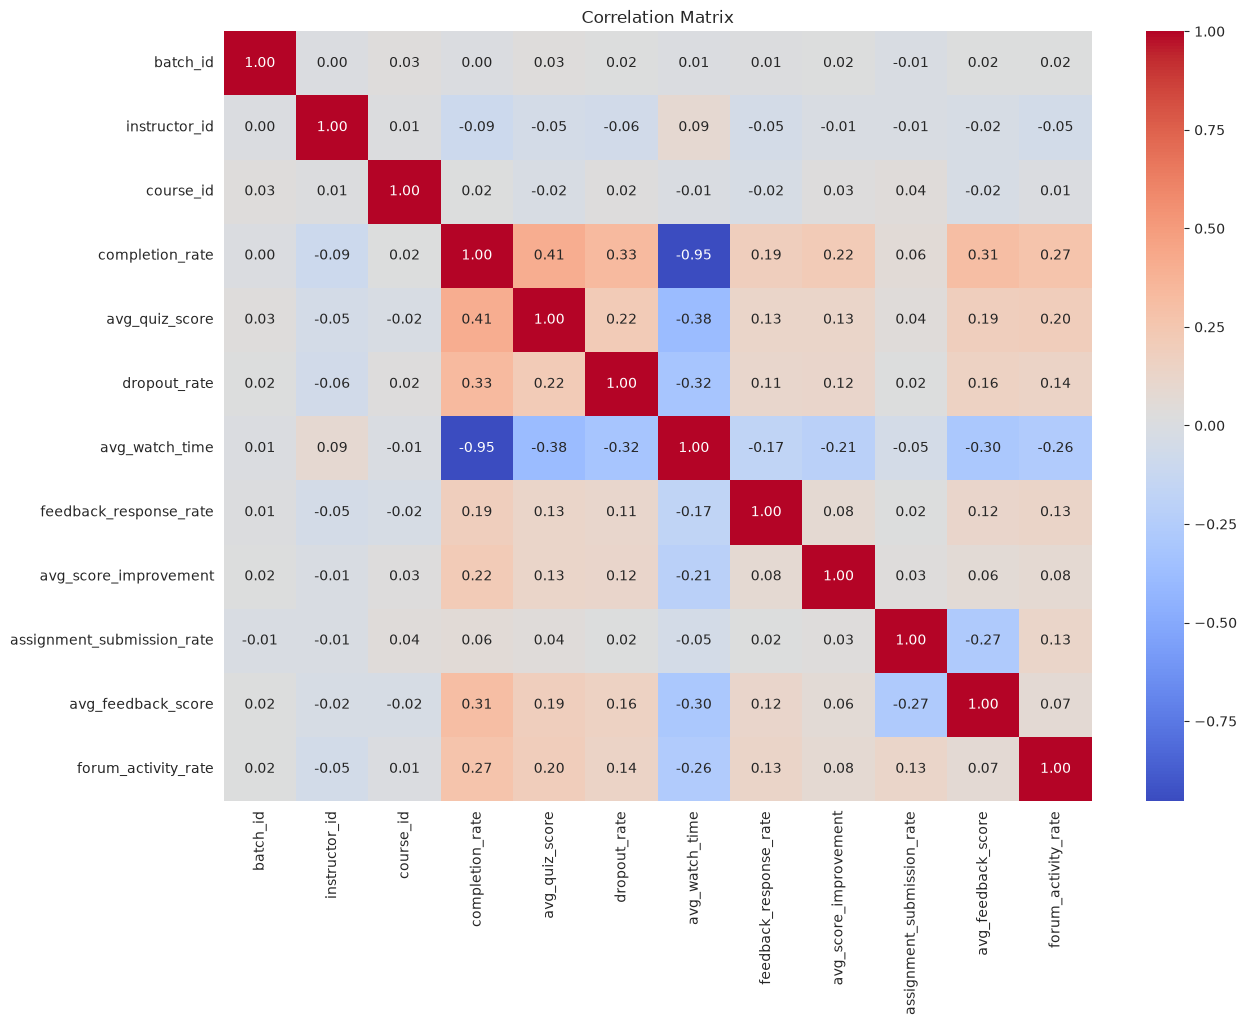

In [14]:
# Visualize feature correlations
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

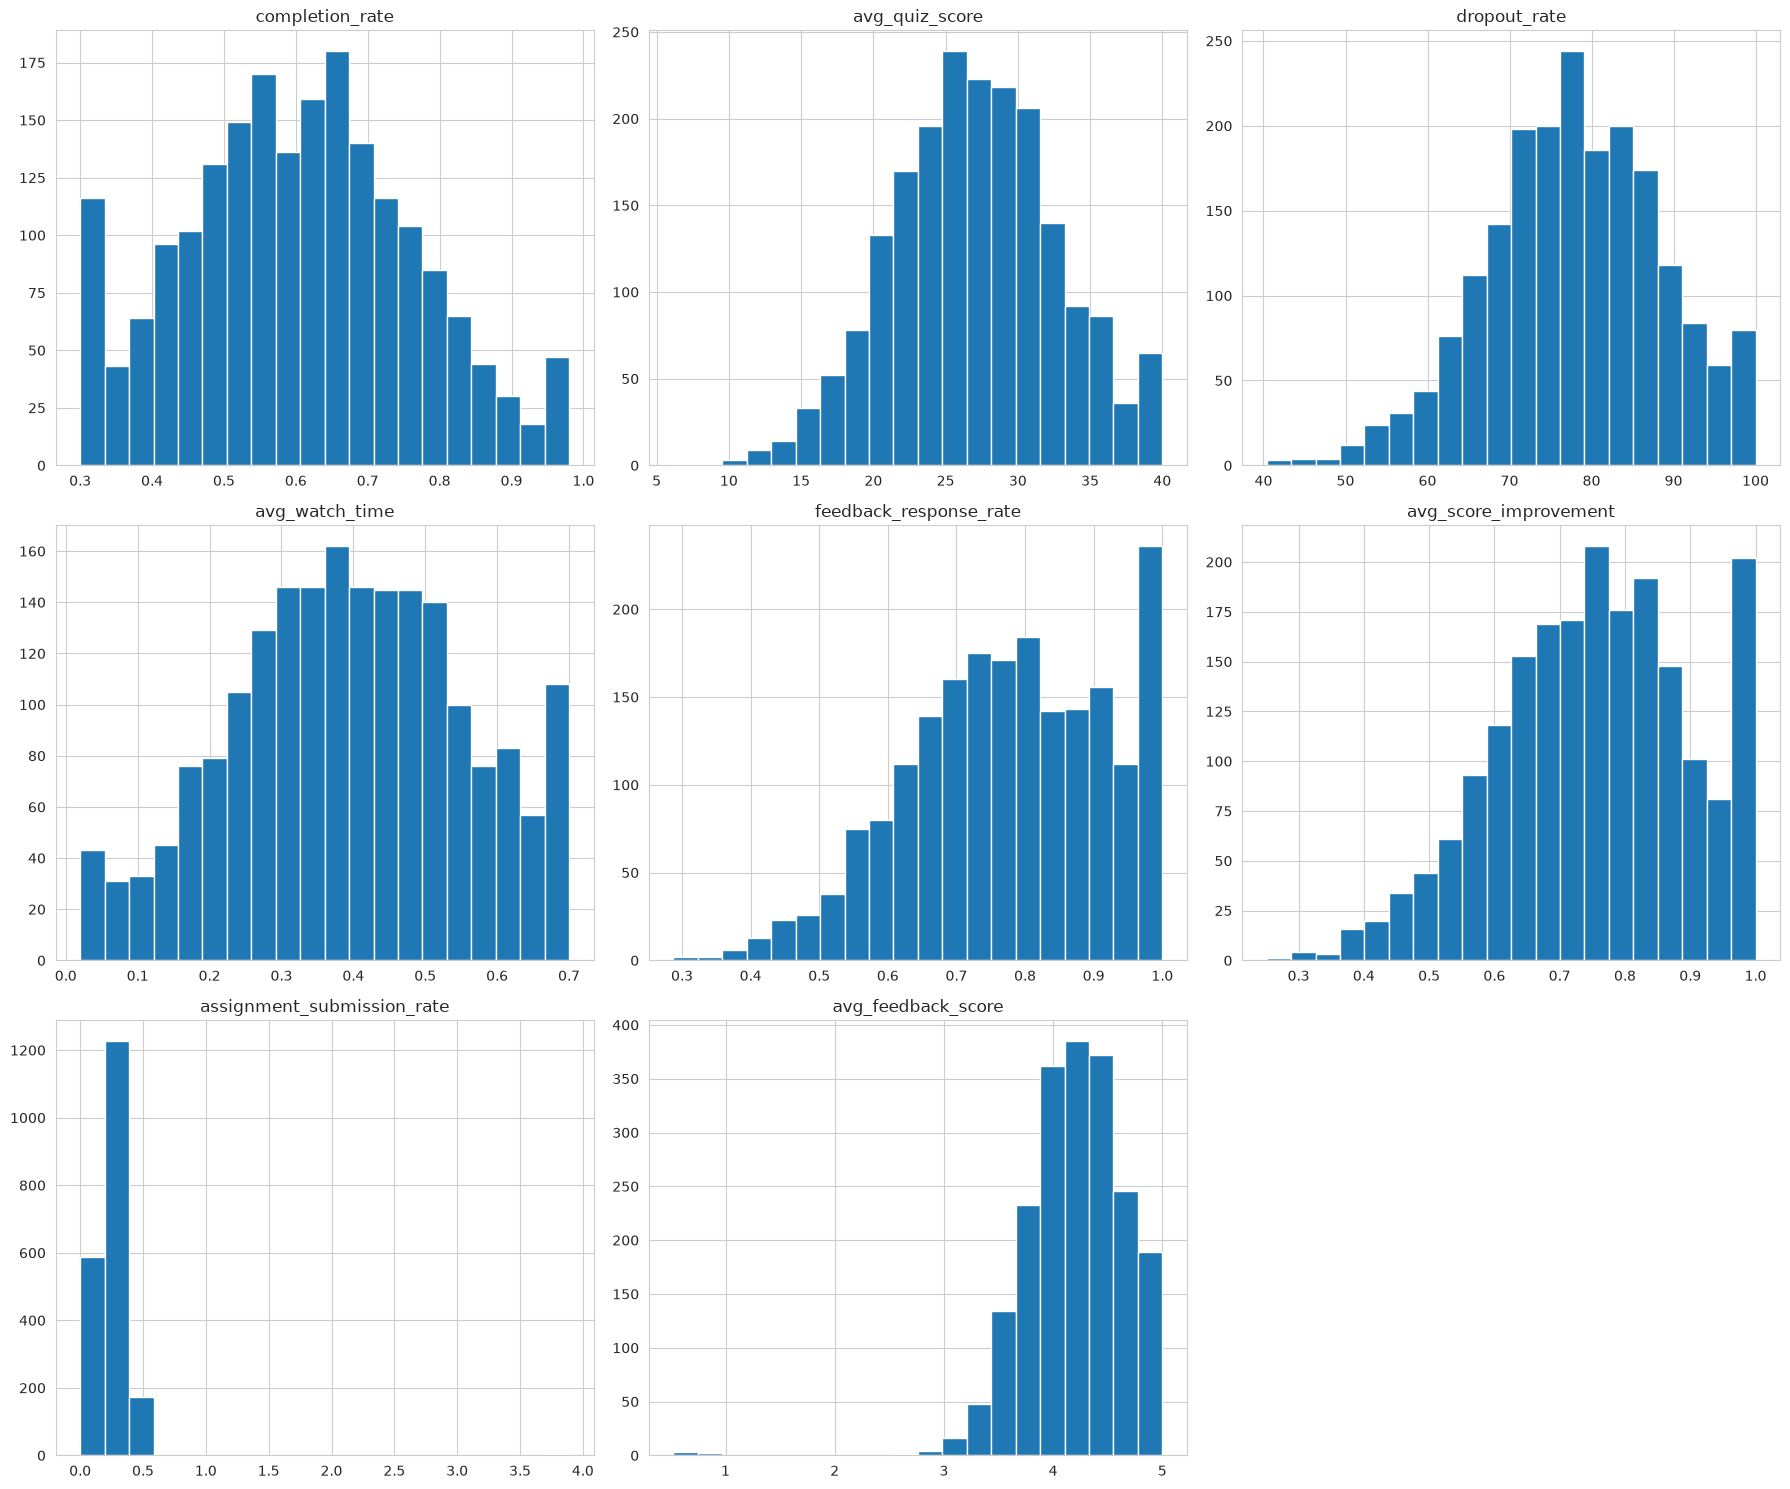

In [15]:
# Plot distributions of numerical features
df[numerical_cols].hist(figsize=(18, 15), bins=20)

plt.tight_layout()
plt.show()

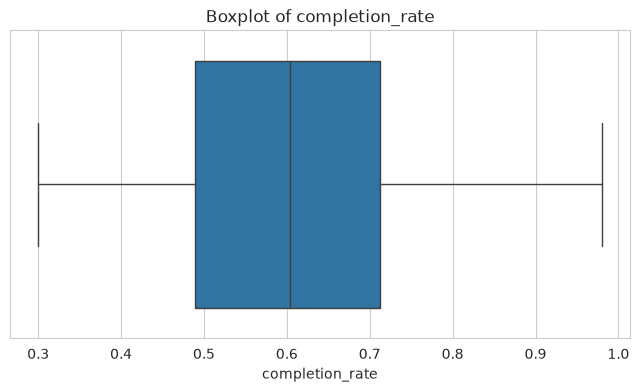

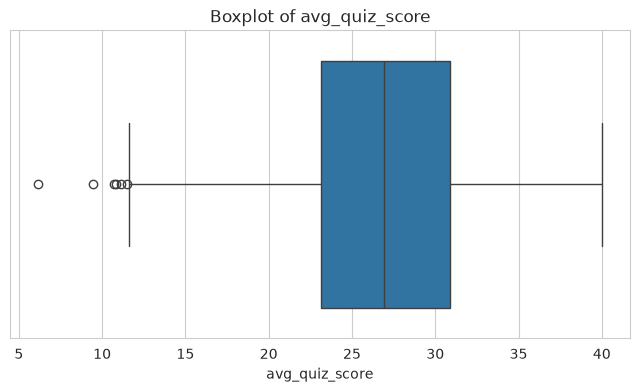

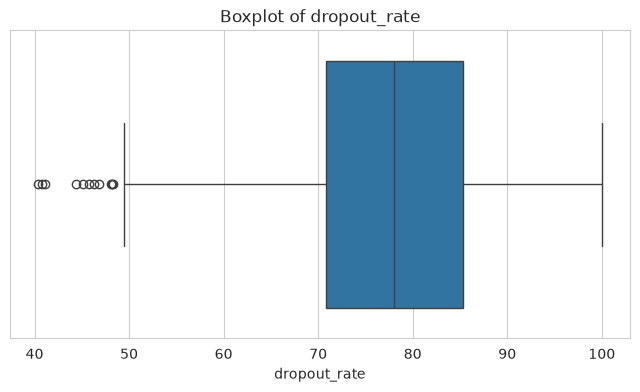

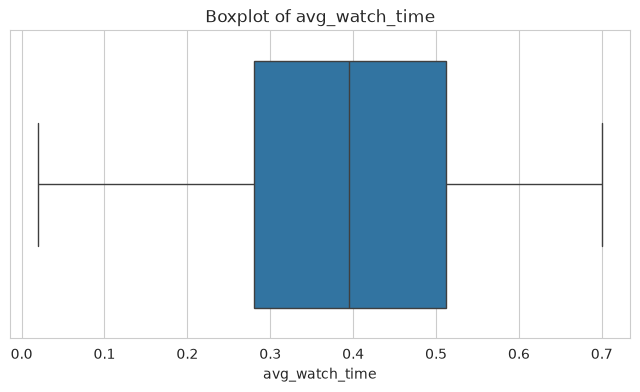

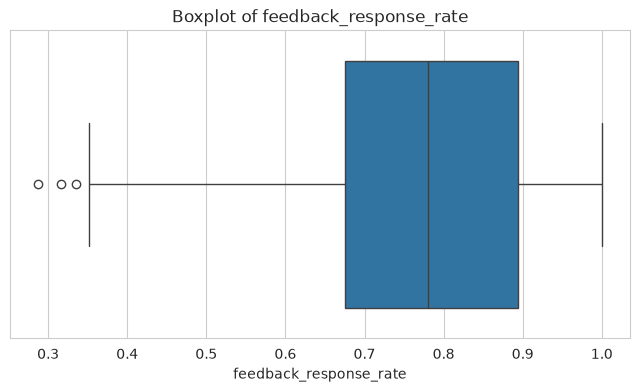

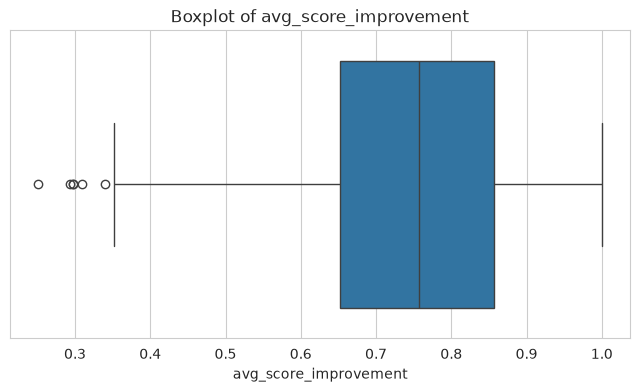

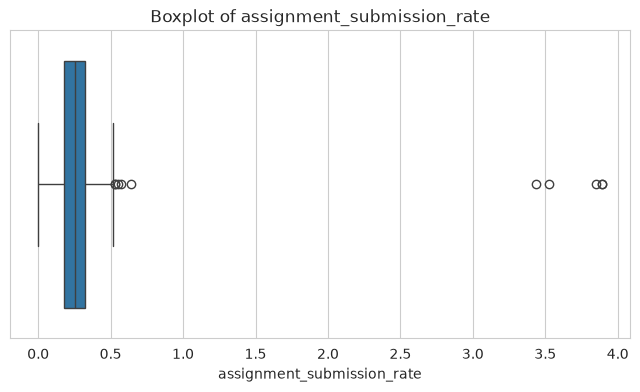

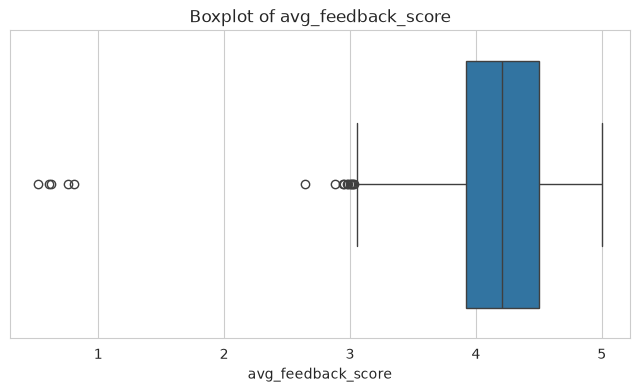

In [16]:
# Display boxplots for numerical features
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [17]:
# Preview processed dataset
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_quiz_score,dropout_rate,avg_watch_time,feedback_response_rate,avg_score_improvement,assignment_submission_rate,avg_feedback_score,forum_activity_rate
0,1855,43,0,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,182
1,352,118,5,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,972
2,1330,49,2,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,713
3,903,23,20,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1896
4,1286,0,7,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,789


## 📊 Exploratory Data Analysis

In this stage, we explore important patterns in the dataset using visualizations. The goal is to understand feature relationships, instructor performance trends, distribution of key metrics, and factors that may influence the final effectiveness score.

In [19]:
# Display all column names
print(df.columns.tolist())

['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'feedback_response_rate', 'avg_score_improvement', 'assignment_submission_rate', 'avg_feedback_score', 'forum_activity_rate']


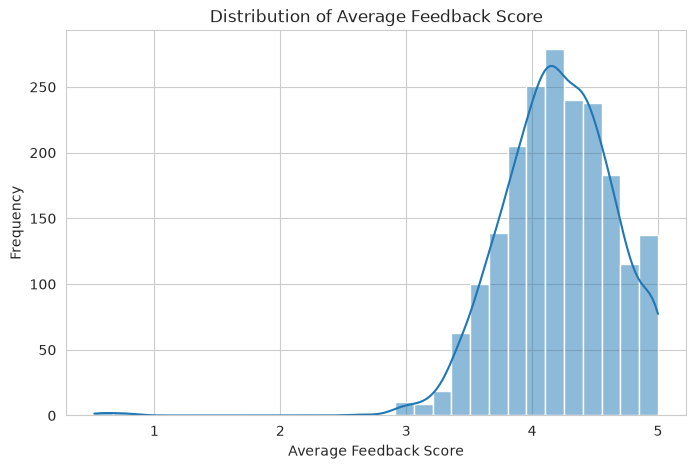

In [20]:
# Visualize the distribution of the target variable
target_col = "avg_feedback_score"

plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], kde=True, bins=30)
plt.title("Distribution of Average Feedback Score")
plt.xlabel("Average Feedback Score")
plt.ylabel("Frequency")
plt.show()

In [21]:
# Calculate correlation of all features with the target variable
target_col = "completion_rate"

target_corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)

target_corr

completion_rate               1.000000
avg_quiz_score                0.405048
dropout_rate                  0.334130
avg_feedback_score            0.308197
forum_activity_rate           0.268597
avg_score_improvement         0.220843
feedback_response_rate        0.187463
assignment_submission_rate    0.057692
course_id                     0.016178
batch_id                      0.001230
instructor_id                -0.093365
avg_watch_time               -0.953460
Name: completion_rate, dtype: float64

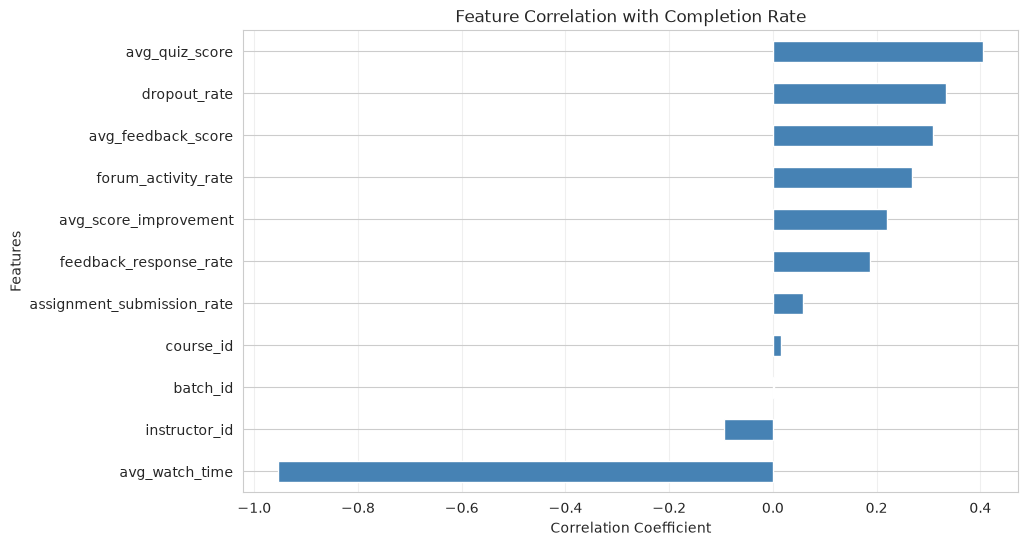

In [22]:
# Visualize correlation of features with completion rate
plt.figure(figsize=(10, 6))

target_corr.drop(target_col).sort_values().plot(kind="barh", color="steelblue")

plt.title("Feature Correlation with Completion Rate")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.grid(axis="x", alpha=0.3)
plt.show()

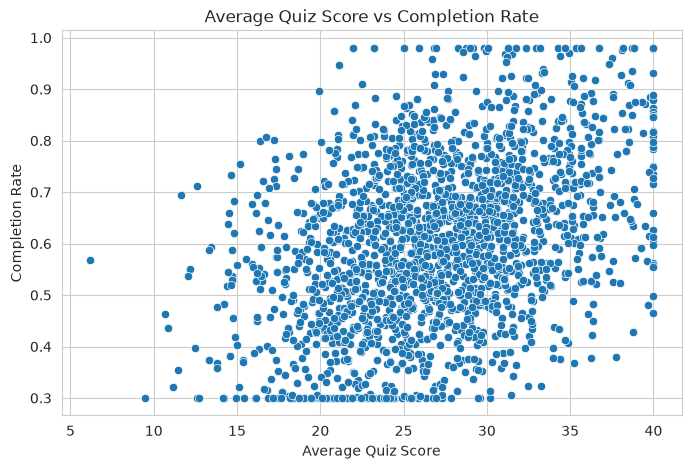

In [23]:
# Analyze relationship between quiz score and completion rate
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_quiz_score",
    y=target_col
)

plt.title("Average Quiz Score vs Completion Rate")
plt.xlabel("Average Quiz Score")
plt.ylabel("Completion Rate")

plt.show()

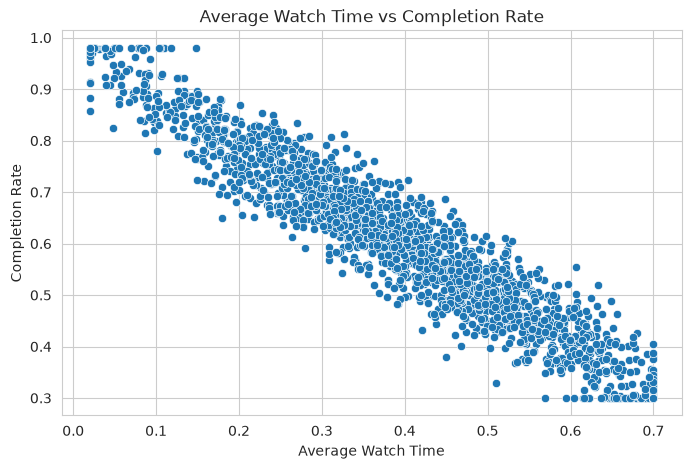

In [24]:
# Analyze relationship between watch time and completion rate
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_watch_time",
    y=target_col
)

plt.title("Average Watch Time vs Completion Rate")
plt.xlabel("Average Watch Time")
plt.ylabel("Completion Rate")

plt.show()

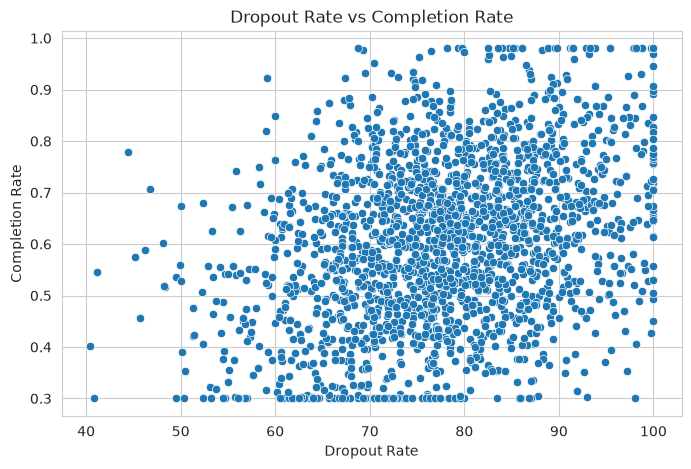

In [25]:
# Analyze relationship between dropout rate and completion rate
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="dropout_rate",
    y=target_col
)

plt.title("Dropout Rate vs Completion Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Completion Rate")

plt.show()

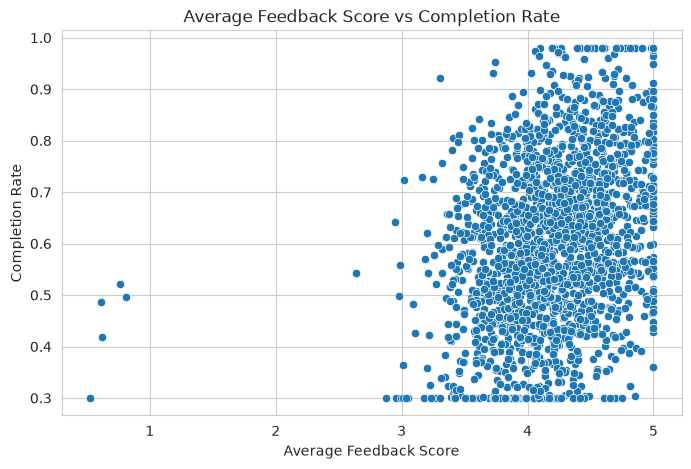

In [26]:
# Analyze relationship between feedback score and completion rate
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_feedback_score",
    y=target_col
)

plt.title("Average Feedback Score vs Completion Rate")
plt.xlabel("Average Feedback Score")
plt.ylabel("Completion Rate")

plt.show()

In [27]:
# Create output folders for final saved artifacts
import os

os.makedirs("../outputs/reports", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

## 🤖 Model Development

In this stage, the dataset is prepared for machine learning by selecting the target variable, splitting the data into training and testing sets, scaling the features where appropriate, and training multiple regression models. The performance of each model will be evaluated using standard regression metrics to identify the most effective predictive approach.

In [28]:
# Separate features and target variable
target_col = "completion_rate"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (1995, 11)
Target Shape: (1995,)


In [29]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (1596, 11)
Testing Set : (399, 11)


In [30]:
# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 📈 Baseline Model

Linear Regression serves as the baseline model for evaluating the relationship between educational engagement metrics and course completion rate. The performance of more advanced machine learning models will be compared against this benchmark.

In [31]:
# Train Linear Regression model
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

In [32]:
# Evaluate Linear Regression performance
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

MAE  : 0.0392
RMSE : 0.0495
R²   : 0.8999


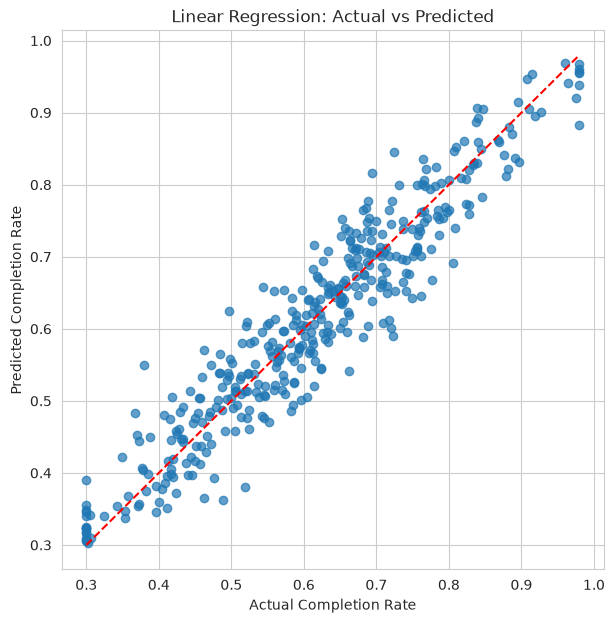

In [33]:
# Compare actual and predicted values
plt.figure(figsize=(7,7))

plt.scatter(y_test, linear_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Completion Rate")
plt.ylabel("Predicted Completion Rate")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

## 🌳 Tree-Based Machine Learning Models

Tree-based ensemble models are capable of capturing complex, non-linear relationships within educational data. In this section, Decision Tree, Random Forest, Gradient Boosting, and XGBoost regressors are trained and evaluated to identify the most accurate predictive model.

In [34]:
# Train Decision Tree Regressor
decision_tree = DecisionTreeRegressor(random_state=42)

decision_tree.fit(X_train, y_train)

decision_tree_predictions = decision_tree.predict(X_test)

In [35]:
# Train Random Forest Regressor
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest.fit(X_train, y_train)

random_forest_predictions = random_forest.predict(X_test)

In [36]:
# Train Gradient Boosting Regressor
gradient_boost = GradientBoostingRegressor(random_state=42)

gradient_boost.fit(X_train, y_train)

gradient_predictions = gradient_boost.predict(X_test)

In [37]:
# Train XGBoost Regressor
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

In [38]:
# Define evaluation function
def evaluate_model(model_name, y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return [model_name, mae, rmse, r2]

In [39]:
# Compare model performance
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_predictions
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions
    )
)

comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

comparison.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.039215,0.049496,0.899926
1,Gradient Boosting,0.040815,0.051911,0.889922
2,Random Forest,0.041405,0.051985,0.889607
3,XGBoost,0.044550,0.055815,0.872741
4,Decision Tree,0.053262,0.068173,0.810152


In [40]:
# Save model comparison report
comparison.to_csv(
    "../outputs/reports/model_comparison.csv",
    index=False
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.039215,0.049496,0.899926
1,Gradient Boosting,0.040815,0.051911,0.889922
2,Random Forest,0.041405,0.051985,0.889607
3,XGBoost,0.044550,0.055815,0.872741
4,Decision Tree,0.053262,0.068173,0.810152


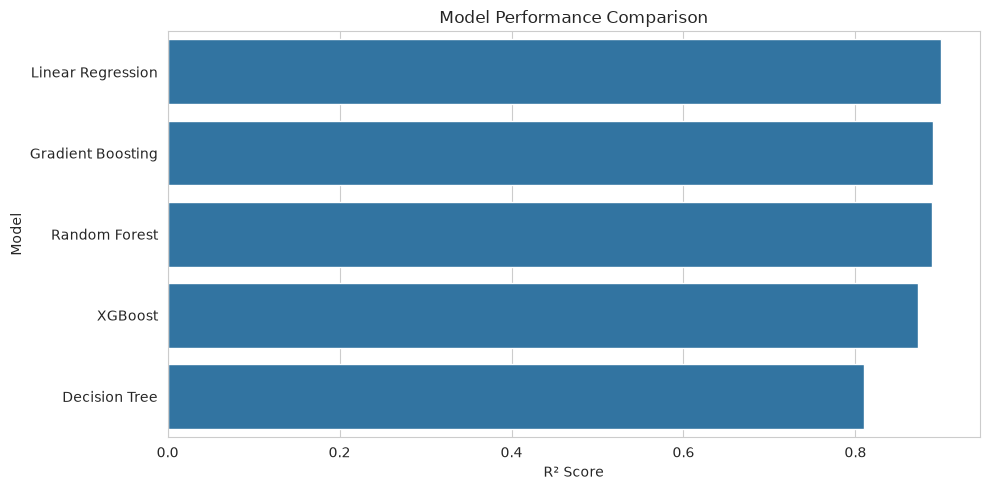

In [41]:
# Visualize model comparison
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="R2 Score",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison.png",
    dpi=300
)

plt.show()

## ⭐ Feature Importance Analysis

Since Linear Regression achieved the highest predictive performance, it is selected as the final model. The model coefficients are analyzed to understand how each feature contributes to predicting course completion rate.

In [43]:
# Analyze feature importance using Linear Regression coefficients
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
5,avg_watch_time,-0.146799,0.146799
3,avg_quiz_score,0.005472,0.005472
4,dropout_rate,0.004827,0.004827
9,avg_feedback_score,0.003516,0.003516
7,avg_score_improvement,0.003190,0.003190
8,assignment_submission_rate,0.002979,0.002979
6,feedback_response_rate,0.002969,0.002969
2,course_id,0.001990,0.001990
10,forum_activity_rate,0.001795,0.001795
0,batch_id,0.000543,0.000543


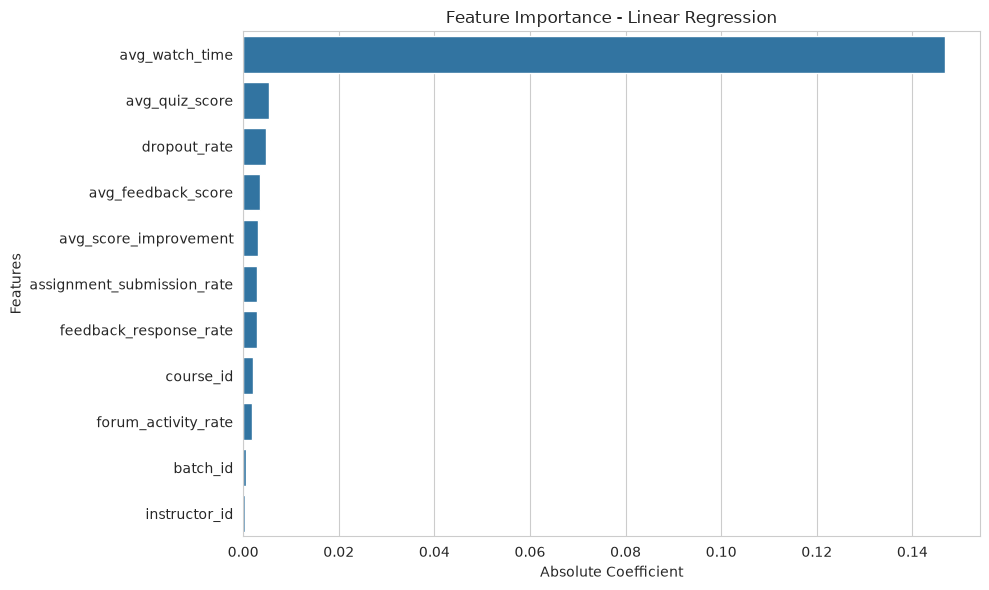

In [44]:
# Visualize feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Absolute Coefficient",
    y="Feature"
)

plt.title("Feature Importance - Linear Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/feature_importance.png",
    dpi=300
)

plt.show()

## 💾 Model Persistence

The best-performing model is saved for future inference and deployment. This allows the trained model to be reused without retraining.

In [45]:
# Save the trained model
import joblib

joblib.dump(
    linear_model,
    "../models/best_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## 🎯 Prediction Results

The trained model is used to generate predictions on the test dataset. These predictions are stored for future evaluation and analysis.

In [46]:
# Save predictions
predictions = pd.DataFrame({
    "Actual Completion Rate": y_test.values,
    "Predicted Completion Rate": linear_predictions
})

predictions.to_csv(
    "../outputs/reports/predictions.csv",
    index=False
)

predictions.head()

,Actual Completion Rate,Predicted Completion Rate
0,0.494379,0.502093
1,0.613594,0.716023
2,0.562075,0.546841
3,0.717845,0.764466
4,0.496603,0.534721


## 📉 Residual Analysis

Residual analysis helps evaluate prediction errors by comparing the difference between actual and predicted completion rates. A random distribution of residuals indicates that the model fits the data well.

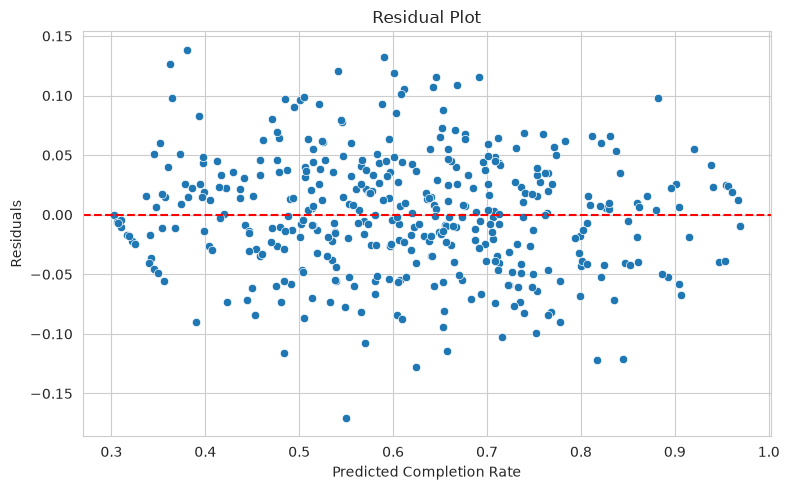

In [47]:
# Visualize prediction residuals
residuals = y_test - linear_predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=linear_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Completion Rate")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/residual_plot.png",
    dpi=300
)

plt.show()

## 💡 Business Insights

Based on the exploratory analysis and machine learning results, several factors were identified as influential in predicting course completion rate.

The findings provide actionable insights that educational institutions can use to improve learner engagement, reduce dropout rates, and enhance overall course outcomes.

In [48]:
# Display the five most influential features
feature_importance.head(5)

,Feature,Coefficient,Absolute Coefficient
5,avg_watch_time,-0.146799,0.146799
3,avg_quiz_score,0.005472,0.005472
4,dropout_rate,0.004827,0.004827
9,avg_feedback_score,0.003516,0.003516
7,avg_score_improvement,0.003190,0.003190


### Key Observations

- Features with larger absolute coefficients contribute more significantly to predicting course completion rate.
- Positive coefficients indicate a positive influence on completion rate, while negative coefficients indicate an inverse relationship.
- Linear Regression achieved the highest R² score among all evaluated models, suggesting that the relationship between engagement metrics and completion rate is predominantly linear.

## ✅ Conclusion

EduPulse successfully analyzed instructor and learner engagement metrics to predict course completion rate using multiple machine learning algorithms.

Several regression models were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Based on evaluation metrics, Linear Regression demonstrated the best overall predictive performance and was selected as the final model.

The project highlights how educational analytics can support data-driven decision-making by identifying factors that influence learner success and enabling institutions to proactively improve course outcomes.

## 🚀 Future Scope

Potential enhancements for this project include:

- Integrating real-time learner activity data.
- Deploying the trained model as a REST API.
- Building an interactive analytics dashboard.
- Incorporating explainable AI techniques such as SHAP and LIME.
- Training deep learning models on larger educational datasets.
- Developing early warning systems for identifying at-risk learners.

In [49]:
# Save processed dataset
df.to_csv(
    "../outputs/reports/cleaned_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [50]:
# Display final project summary
print("=" * 60)
print("EduPulse - Instructor Analytics Pipeline Completed")
print("=" * 60)

print(f"Dataset Shape        : {df.shape}")
print(f"Features Used        : {X.shape[1]}")
print(f"Target Variable      : {target_col}")
print(f"Best Model           : Linear Regression")
print(f"Best R² Score        : {linear_r2:.4f}")

print("\nArtifacts Generated")
print("- Model Comparison Report")
print("- Predictions")
print("- Cleaned Dataset")
print("- Feature Importance Plot")
print("- Residual Plot")
print("- Best Trained Model (.pkl)")

print("\nProject completed successfully.")

EduPulse - Instructor Analytics Pipeline Completed
Dataset Shape        : (1995, 12)
Features Used        : 11
Target Variable      : completion_rate
Best Model           : Linear Regression
Best R² Score        : 0.8999

Artifacts Generated
- Model Comparison Report
- Predictions
- Cleaned Dataset
- Feature Importance Plot
- Residual Plot
- Best Trained Model (.pkl)

Project completed successfully.


In [51]:
# Save processed dataset
df.to_csv(
    "../data/processed/processed_instructor_effectiveness.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
